In [100]:
import pykep as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go
import pygmo as pg

In [2]:

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the data
planets = pd.read_csv('./content/gtoc13_planets.csv', encoding='latin1')
asteroids = pd.read_csv('./content/gtoc13_asteroids.csv', encoding='latin1')
comets = pd.read_csv('./content/gtoc13_comets.csv', encoding='latin1')

# Constants
AU = 149597870.691  # km
MU_ALTAIRA = 139348062043.343  # km³/s²
YEAR_SEC = 365.25 * 86400  # seconds
DEG2RAD = np.pi / 180

print("=== GTOC13 SYSTEM OVERVIEW ===")
print(f"Number of planets: {len(planets)}")
print(f"Number of asteroids: {len(asteroids)}")
print(f"Number of comets: {len(comets)}")
print(f"Total bodies: {len(planets) + len(asteroids) + len(comets)}")

=== GTOC13 SYSTEM OVERVIEW ===
Number of planets: 11
Number of asteroids: 257
Number of comets: 42
Total bodies: 310


In [3]:
# 1. SYSTEM ARCHITECTURE ANALYSIS

def calculate_orbital_period(semi_major_axis_km):
    """Calculate orbital period in years"""
    a = semi_major_axis_km  # km
    return 2 * np.pi * np.sqrt(a**3 / MU_ALTAIRA) / YEAR_SEC

def calculate_orbital_velocity(semi_major_axis_km, distance_km=None):
    """Calculate orbital velocity at given distance"""
    if distance_km is None:
        distance_km = semi_major_axis_km
    return np.sqrt(MU_ALTAIRA * (2/distance_km - 1/semi_major_axis_km))

# Add orbital periods to all bodies
planets['orbital_period_yrs'] = calculate_orbital_period(planets['Semi-Major Axis (km)'])
asteroids['orbital_period_yrs'] = calculate_orbital_period(asteroids['Semi-Major Axis (km)'])
comets['orbital_period_yrs'] = calculate_orbital_period(comets['Semi-Major Axis (km)'])

# Convert semi-major axis to AU for easier interpretation
planets['semi_major_axis_AU'] = planets['Semi-Major Axis (km)'] / AU
asteroids['semi_major_axis_AU'] = asteroids['Semi-Major Axis (km)'] / AU
comets['semi_major_axis_AU'] = comets['Semi-Major Axis (km)'] / AU

print("\n=== PLANETARY SYSTEM ANALYSIS ===")
print("Planets by semi-major axis (AU):")
for _, planet in planets.sort_values('semi_major_axis_AU').iterrows():
    print(f"{planet['Name']:12} | a = {planet['semi_major_axis_AU']:8.3f} AU | "
          f"P = {planet['orbital_period_yrs']:6.3f} yrs | "
          f"w = {planet['Weight ()']} | e = {planet['Eccentricity ()']:.3f}")


=== PLANETARY SYSTEM ANALYSIS ===
Planets by semi-major axis (AU):
Vulcan       | a =    0.092 AU | P =  0.027 yrs | w = 0.1 | e = 0.000
Yavin        | a =    0.859 AU | P =  0.777 yrs | w = 1.0 | e = 0.050
Eden         | a =    1.200 AU | P =  1.283 yrs | w = 2.0 | e = 0.007
Hoth         | a =    2.939 AU | P =  4.916 yrs | w = 3.0 | e = 0.050
Yandi        | a =    3.986 AU | P =  7.767 yrs | w = 5.0 | e = 0.077
Beyoncé      | a =    7.481 AU | P = 19.968 yrs | w = 7.0 | e = 0.070
Bespin       | a =   14.295 AU | P = 52.748 yrs | w = 10.0 | e = 0.119
Jotunn       | a =   17.529 AU | P = 71.623 yrs | w = 15.0 | e = 0.150
Wakonyingo   | a =   34.195 AU | P = 195.145 yrs | w = 20.0 | e = 0.095
Rogue1       | a =   67.173 AU | P = 537.289 yrs | w = 35.0 | e = 0.100
PlanetX      | a =  106.653 AU | P = 1074.908 yrs | w = 50.0 | e = 0.345


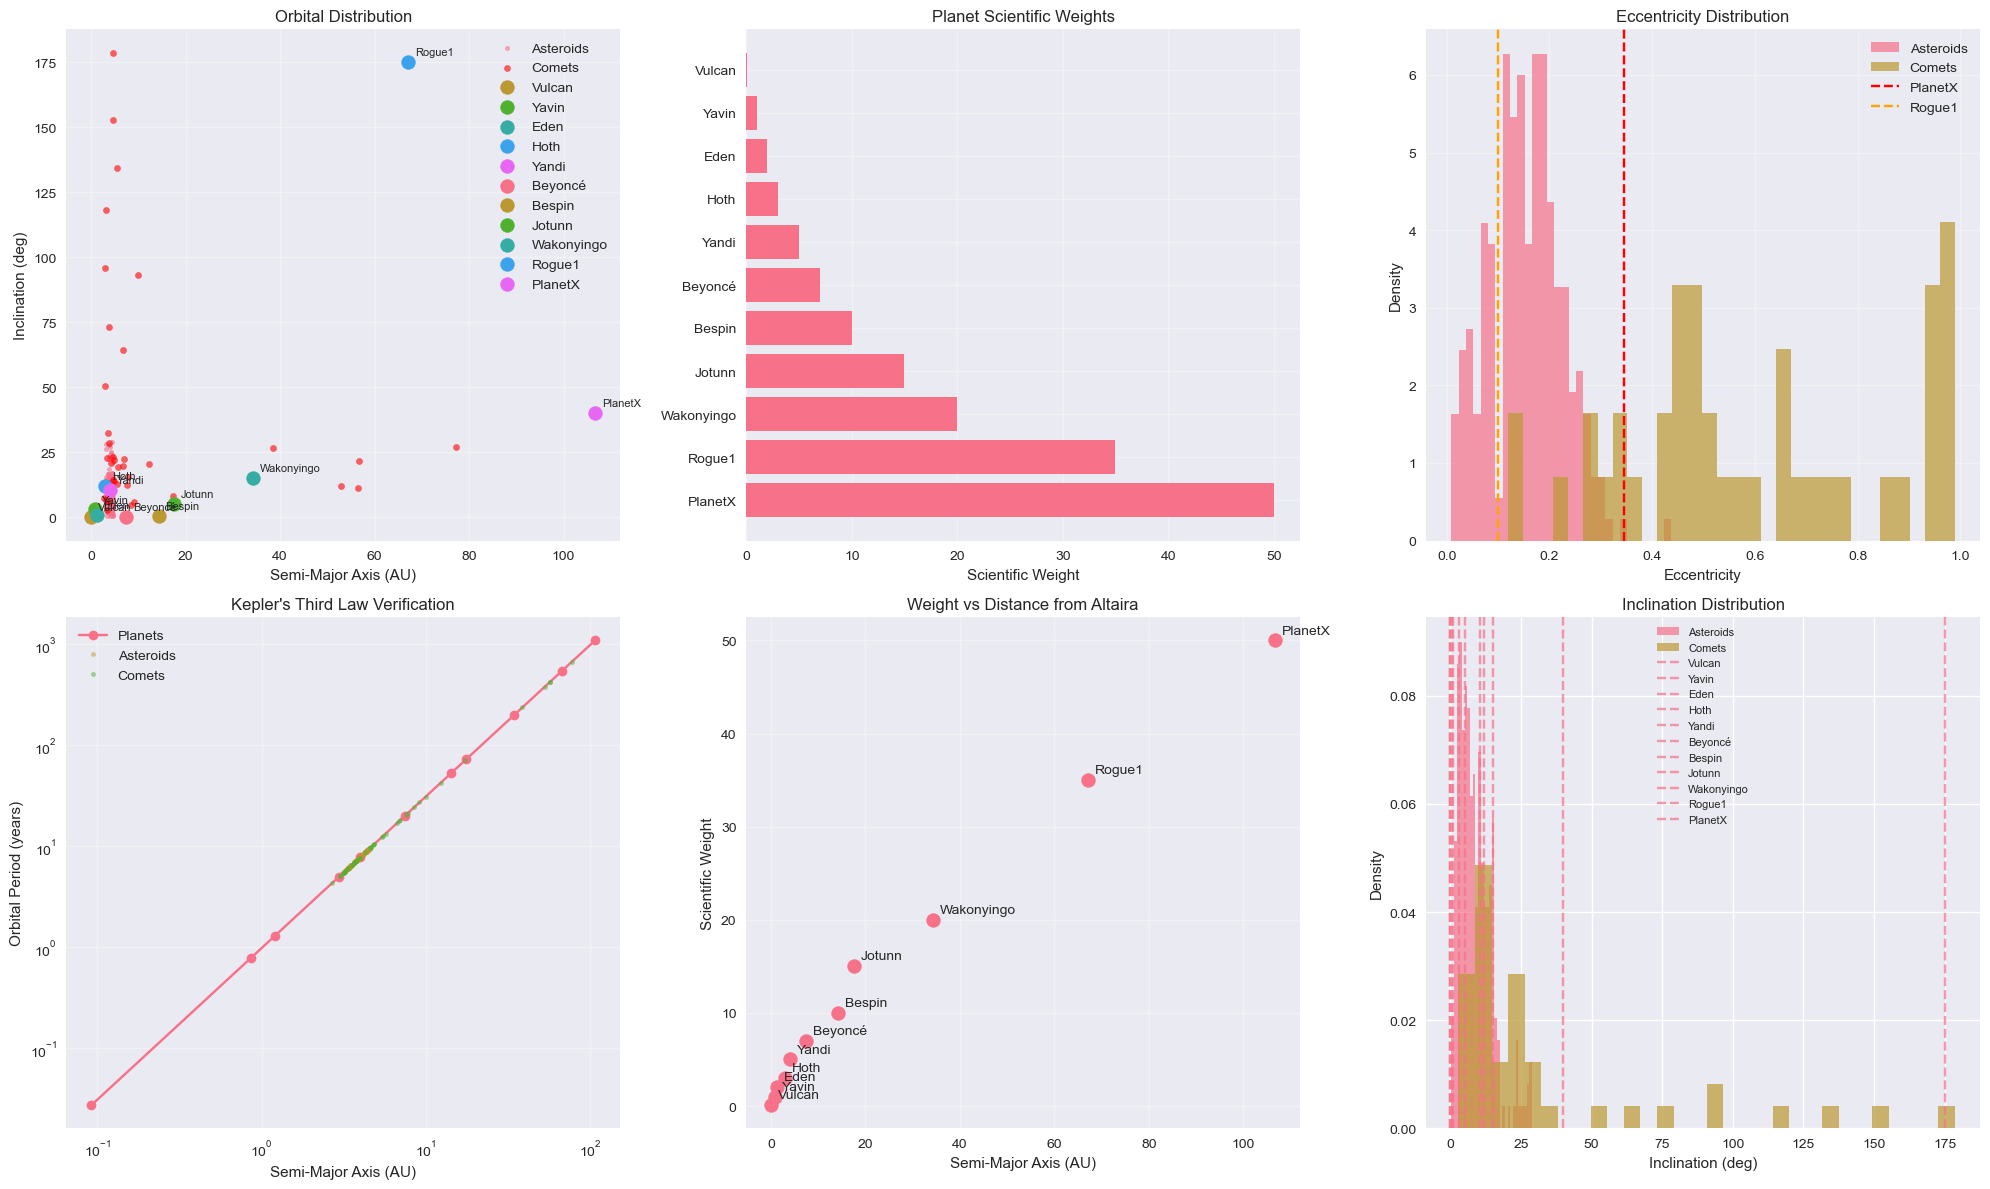

In [4]:
# Create comprehensive system visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Semi-major axis distribution
all_bodies = pd.concat([
    planets[['semi_major_axis_AU', 'Weight ()', 'Name']].assign(type='Planet'),
    asteroids[['semi_major_axis_AU', 'Weight ()']].assign(type='Asteroid', Name=''),
    comets[['semi_major_axis_AU', 'Weight ()']].assign(type='Comet', Name='')
])

axes[0,0].scatter(asteroids['semi_major_axis_AU'], asteroids['Inclination (deg)'],
                 alpha=0.6, s=10, label='Asteroids')
axes[0,0].scatter(comets['semi_major_axis_AU'], comets['Inclination (deg)'],
                 alpha=0.6, s=20, label='Comets', color='red')
for _, planet in planets.iterrows():
    axes[0,0].scatter(planet['semi_major_axis_AU'], planet['Inclination (deg)'],
                     s=100, label=planet['Name'])
    axes[0,0].annotate(planet['Name'],
                      (planet['semi_major_axis_AU'], planet['Inclination (deg)']),
                      xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[0,0].set_xlabel('Semi-Major Axis (AU)')
axes[0,0].set_ylabel('Inclination (deg)')
axes[0,0].set_title('Orbital Distribution')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Weight distribution
weights_data = []
for _, planet in planets.iterrows():
    weights_data.append({'Name': planet['Name'], 'Weight': planet['Weight ()'], 'Type': 'Planet'})
for _, asteroid in asteroids.iterrows():
    weights_data.append({'Name': f"Asteroid {asteroid['#Asteroid ID']}",
                       'Weight': asteroid['Weight ()'], 'Type': 'Asteroid'})
for _, comet in comets.iterrows():
    weights_data.append({'Name': f"Comet {comet['# Comet ID']}",
                       'Weight': comet['Weight ()'], 'Type': 'Comet'})
weights_df = pd.DataFrame(weights_data)

planet_weights = planets[['Name', 'Weight ()']].sort_values('Weight ()', ascending=False)
axes[0,1].barh(planet_weights['Name'], planet_weights['Weight ()'])
axes[0,1].set_xlabel('Scientific Weight')
axes[0,1].set_title('Planet Scientific Weights')
axes[0,1].grid(True, alpha=0.3)

# 3. Eccentricity distribution
axes[0,2].hist(asteroids['Eccentricity ()'], bins=30, alpha=0.7, label='Asteroids', density=True)
axes[0,2].hist(comets['Eccentricity ()'], bins=30, alpha=0.7, label='Comets', density=True)
axes[0,2].axvline(planets.loc[planets['Name'] == 'PlanetX', 'Eccentricity ()'].values[0],
                 color='red', linestyle='--', label='PlanetX')
axes[0,2].axvline(planets.loc[planets['Name'] == 'Rogue1', 'Eccentricity ()'].values[0],
                 color='orange', linestyle='--', label='Rogue1')
axes[0,2].set_xlabel('Eccentricity')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Eccentricity Distribution')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Orbital period vs semi-major axis (log-log)
axes[1,0].loglog(planets['semi_major_axis_AU'], planets['orbital_period_yrs'], 'o-', label='Planets')
axes[1,0].loglog(asteroids['semi_major_axis_AU'], asteroids['orbital_period_yrs'], '.',
                alpha=0.5, label='Asteroids')
axes[1,0].loglog(comets['semi_major_axis_AU'], comets['orbital_period_yrs'], '.',
                alpha=0.5, label='Comets')
axes[1,0].set_xlabel('Semi-Major Axis (AU)')
axes[1,0].set_ylabel('Orbital Period (years)')
axes[1,0].set_title('Kepler\'s Third Law Verification')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Weight vs accessibility (semi-major axis)
axes[1,1].scatter(planets['semi_major_axis_AU'], planets['Weight ()'], s=100)
for _, planet in planets.iterrows():
    axes[1,1].annotate(planet['Name'],
                      (planet['semi_major_axis_AU'], planet['Weight ()']),
                      xytext=(5, 5), textcoords='offset points')
axes[1,1].set_xlabel('Semi-Major Axis (AU)')
axes[1,1].set_ylabel('Scientific Weight')
axes[1,1].set_title('Weight vs Distance from Altaira')
axes[1,1].grid(True, alpha=0.3)

# 6. Inclination distribution
axes[1,2].hist(asteroids['Inclination (deg)'], bins=30, alpha=0.7, label='Asteroids', density=True)
axes[1,2].hist(comets['Inclination (deg)'], bins=30, alpha=0.7, label='Comets', density=True)
for _, planet in planets.iterrows():
    axes[1,2].axvline(planet['Inclination (deg)'], linestyle='--',
                     label=planet['Name'], alpha=0.7)
axes[1,2].set_xlabel('Inclination (deg)')
axes[1,2].set_ylabel('Density')
axes[1,2].set_title('Inclination Distribution')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Constants
AU = 149597870.691  # km
MU_ALTAIRA = 139348062043.343  # km³/s²
YEAR_SEC = 365.25 * 86400  # seconds

class GTOC13Visualizer:
    def __init__(self, planets_df, asteroids_df, comets_df):
        self.planets = planets_df
        self.asteroids = asteroids_df
        self.comets = comets_df

        # Solar sail parameters
        self.sail_C = 5.4026e-6   # N/m²
        self.sail_A = 15000      # m²
        self.sail_m = 500    # kg
        self.sail_r0 = AU      # km
        
        # Problem constraints
        self.max_time = 200 * YEAR_SEC  # 200 years in seconds
        self.min_flyby_altitude_ratio = 0.1
        self.max_flyby_altitude_ratio = 100.0
        self.min_perihelion = 0.05 * AU  # 0.05 AU in km
        self.single_low_perihelion = 0.01 * AU  # 0.01 AU in km
        self.min_flyby_interval_ratio = 1/3  # Minimum interval between successive flybys of same body
        # Body information dictionary
        self.bodies = {}
        # Add planets
        for _, planet in self.planets.iterrows():
            self.bodies[planet['#Planet ID']] = {
                'name': planet['Name'],
                'GM': planet['GM (km3/s2)'],
                'radius': planet['Radius (km)'],
                'weight': planet['Weight ()'],
                'a': planet['Semi-Major Axis (km)'],
                'e': planet['Eccentricity ()'],
                'i': np.radians(planet['Inclination (deg)']),
                'Omega': np.radians(planet['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(planet['Argument of Periapsis (deg)']),
                'M0': np.radians(planet['Mean Anomaly at t=0 (deg)']),
                'type': 'Planet'
            }

        # Add a sample of asteroids
        asteroid_sample = self.asteroids.sample(n=min(10, len(self.asteroids)), random_state=42) # Consistent sample
        for _, asteroid in asteroid_sample.iterrows():
             self.bodies[asteroid['#Asteroid ID']] = {
                'name': f"Ast {asteroid['#Asteroid ID']}",
                'GM': 0.0, # Assume massless for visualization
                'radius': 0.0,
                'weight': asteroid['Weight ()'],
                'a': asteroid['Semi-Major Axis (km)'],
                'e': asteroid['Eccentricity ()'],
                'i': np.radians(asteroid['Inclination (deg)']),
                'Omega': np.radians(asteroid['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(asteroid['Argument of Periapsis (deg)']), # Corrected column name
                'M0': np.radians(asteroid['Mean Anomaly at t=0']), # Corrected column name
                'type': 'Asteroid'
            }

        # Add a sample of comets
        comet_sample = self.comets.sample(n=min(10, len(self.comets)), random_state=42) # Consistent sample
        for _, comet in comet_sample.iterrows():
             self.bodies[comet['# Comet ID']] = {
                'name': f"Com {comet['# Comet ID']}",
                'GM': 0.0, # Assume massless for visualization
                'radius': 0.0,
                'weight': comet['Weight ()'],
                'a': comet['Semi-Major Axis (km)'],
                'e': comet['Eccentricity ()'],
                'i': np.radians(comet['Inclination (deg)']),
                'Omega': np.radians(comet['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(comet['Argument of Periapsis (deg)']), # Corrected column name
                'M0': np.radians(comet['Mean Anomaly at t=0 (deg)']), # Corrected column name
                'type': 'Comet'
            }

        # Default initial conditions
        self.default_initial_state = {
            'y0': 5.0,    # AU
            'z0': 2.0,    # AU
            'Vx0': 30.0,  # km/s
            't0': 0.0     # years
        }

        # Animation parameters
        self.time_step = 1.0  # years (fixed as requested)
        self.total_time = 200  # years (fixed as requested)
    def slerp(u0, uf, s):
        """Spherical linear interpolation between two unit vectors."""
        u0 = u0 / np.linalg.norm(u0)
        uf = uf / np.linalg.norm(uf)
        dot = np.clip(np.dot(u0, uf), -1.0, 1.0)
        theta = np.arccos(dot)
        if theta < 1e-8:
            return u0
        return (np.sin((1 - s) * theta) * u0 + np.sin(s * theta) * uf) / np.sin(theta)

    def solar_sail_acceleration(self, r_sc, cone_angle_deg=0):
        """Calculate solar sail acceleration vector"""
        r_norm = np.linalg.norm(r_sc)
        r_hat = r_sc / r_norm

        alpha_rad = np.radians(cone_angle_deg)
        n_hat = r_hat * np.cos(alpha_rad)

        accel_mag = (2 * self.sail_C * self.sail_A / self.sail_m) * (self.sail_r0 / r_norm)**2 * (np.cos(alpha_rad))**2
        accel_vector = accel_mag * n_hat

        return accel_vector * 1e-3  # Convert to km/s²
    
    def solar_sail_acceleration_normal(self, r_sc,u_n ):
        """Calculate solar sail acceleration vector"""
        r_norm = np.linalg.norm(r_sc)
        u_r = -1*r_sc / r_norm

        alpha_rad = np.dot(u_r,u_n)
        if alpha_rad < 0:
            raise ValueError("Solar sail normal vector points away from the Sun.")


        accel_mag = (2 * self.sail_C * self.sail_A / self.sail_m) * (self.sail_r0 / r_norm)**2 * (alpha_rad)**2
        accel_vector = -1*accel_mag * u_n

        return accel_vector * 1e-3  # Convert to km/s²

    def spacecraft_dynamics(self, t, y, u_n):
        """Spacecraft dynamics with solar sail"""
        r = y[:3]  # Position vector (km)
        v = y[3:]  # Velocity vector (km/s)

        # Gravitational acceleration from Altaira
        r_norm = np.linalg.norm(r)
        a_gravity = -MU_ALTAIRA * r / r_norm**3

        # Solar sail acceleration
        a_sail = self.solar_sail_acceleration_normal(r, u_n)

        # Total acceleration
        a_total = a_gravity + a_sail

        return np.concatenate([v, a_total])

    def kepler_solver(self, M, e, tolerance=1e-12, max_iter=50):
        """Solve Kepler's equation M = E - e*sin(E) for eccentric anomaly E"""
        E = M  # Initial guess
        for _ in range(max_iter):
            delta_E = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
            E -= delta_E
            if abs(delta_E) < tolerance:
                break
        return E

    def body_state_at_time(self, body_id, t):
        """Get body state (position, velocity) at time t using Keplerian propagation"""
        body = self.bodies[body_id]
        a, e, i, Omega, omega, M0 = body['a'], body['e'], body['i'], body['Omega'], body['omega'], body['M0']
        # Mean motion
        n = np.sqrt(MU_ALTAIRA / a**3)

        # Mean anomaly at time t
        M = M0 + n * t

        # Solve for eccentric anomaly
        E = self.kepler_solver(M, e)

        # True anomaly
        theta = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E/2), np.sqrt(1 - e) * np.cos(E/2))

        # Distance
        r = a * (1 - e * np.cos(E))

        # Position in orbital plane
        x_orb = r * np.cos(theta)
        y_orb = r * np.sin(theta)

        # Velocity in orbital plane
        p = a * (1 - e**2)
        h = np.sqrt(MU_ALTAIRA * p)
        vx_orb = -np.sqrt(MU_ALTAIRA / p) * np.sin(theta)
        vy_orb = np.sqrt(MU_ALTAIRA / p) * (e + np.cos(theta))

        # Rotation matrices
        R_Omega = np.array([
            [np.cos(Omega), -np.sin(Omega), 0],
            [np.sin(Omega), np.cos(Omega), 0],
            [0, 0, 1]
        ])

        R_i = np.array([
            [1, 0, 0],
            [0, np.cos(i), -np.sin(i)],
            [0, np.sin(i), np.cos(i)]
        ])

        R_omega = np.array([
            [np.cos(omega), -np.sin(omega), 0],
            [np.sin(omega), np.cos(omega), 0],
            [0, 0, 1]
        ])

        # Combined rotation
        R = R_Omega @ R_i @ R_omega

        # Transform to inertial frame
        pos_orb = np.array([x_orb, y_orb, 0])
        vel_orb = np.array([vx_orb, vy_orb, 0])

        pos = R @ pos_orb
        vel = R @ vel_orb

        return pos, vel

    def propagate_trajectory(self, initial_state, u_n, time_step_years=1.0, total_time_years=100):
        """Propagate spacecraft trajectory with given initial conditions"""
        # Extract initial conditions
        x0=initial_state*AU     
        y0 = initial_state['y0'] * AU
        z0 = initial_state['z0'] * AU
        Vx0 = initial_state['Vx0']
        Vy0 = initial_state['Vy0']
        Vz0 = initial_state['Vz0']
        t0 = initial_state['t0'] * YEAR_SEC

        # Initial position and velocity
        r0 = np.array([x0, y0, z0])
        v0 = np.array([Vx0,Vy0 , Vz0])

        y0_state = np.concatenate([r0, v0])

        # Time points for propagation (in seconds)
        time_step_sec = time_step_years * YEAR_SEC
        total_time_sec = total_time_years * YEAR_SEC
        t_eval = np.arange(t0, t0 + total_time_sec + time_step_sec, time_step_sec) # Add a small step to ensure last point is included

        # Integrate trajectory
        sol = solve_ivp(
            lambda t, y: self.spacecraft_dynamics(t, y, u_n),
            [t0, t0 + total_time_sec],
            y0_state,
            method='RK45',
            t_eval=t_eval,
            rtol=1e-14,
            atol=1e-14,
            # max_step=72000
        )

        if not sol.success:
            # Check if integration stopped early but still has points
            if sol.status == 1: # Integration successful to the end of interval
                 print(f"Integration successful over requested interval.")
            elif sol.status == 0: # Integration successful to the end of t_eval
                 print(f"Integration successful over specified time points.")
            else:
                raise RuntimeError(f"Integration failed: {sol.message}")


        # Convert to AU for plotting
        positions_au = sol.y[:3].T / AU
        velocities = sol.y[3:].T
        times_years = (sol.t - t0) / YEAR_SEC

        return positions_au, velocities, times_years
    def propagate_continuous_arc(self, r0, v0, u0, uf, t0, tf, dt=86400):
        """Propagate spacecraft trajectory with a continuously varying sail normal vector."""
        def slerp(u_start, u_end, s):
            """Spherical linear interpolation between two unit vectors."""
            u_start = u_start 
            u_end = u_end 
            dot = np.clip(np.dot(u_start, u_end), -1.0, 1.0)
            theta = np.arccos(dot)
            if theta < 1e-8: 
                return u_start
            return (np.sin((1 - s) * theta) * u_start + np.sin(s * theta) * u_end) / np.sin(theta)

        def dynamics(t, y):
            r = y[:3]
            v = y[3:]
            s = np.clip((t - t0) / (tf - t0), 0, 1)
            u_n = slerp(u0, uf, s)
            a_grav = -MU_ALTAIRA * r / np.linalg.norm(r)**3
            a_sail = self.solar_sail_acceleration_normal(r, u_n)
            return np.concatenate([v, a_grav + a_sail])

        # Integration grid
        t_eval = np.arange(t0, tf + dt, dt)
        t_eval = np.clip(t_eval, t0, tf)
        t_eval = np.unique(t_eval)  # remove duplicates if any
        y0 = np.concatenate([r0, v0])

        sol = solve_ivp(dynamics, [t0, tf], y0, t_eval=t_eval, rtol=1e-14, atol=1e-14)

        # Recompute the interpolated u_n(t)
        u_hist = [slerp(u0, uf, (t - t0)/(tf - t0)) for t in sol.t]
        r_hist = sol.y[:3].T
        v_hist = sol.y[3:].T

        #### Export the solution in GTOC13 format
        body_id = 0  # heliocentric
        if np.linalg.norm(u0) == 0:
            flag = 0     # propagated without solar sail
        else:
             flag = 1     # propagated with solar sail       
        for epoch, (r_vec, v_vec, u_vec) in zip(sol.t, zip(r_hist, v_hist, u_hist)):
            x, y, z = r_vec
            vx, vy, vz = v_vec
            ux, uy, uz = u_vec                      
        # print only the first and last line to avoid flooding the output, and print to 6 decimal places for epoch 
        # and 9 decimal places for positions and velocities
        # you can remove this condition to print all lines if needed
            if epoch == sol.t[0] or epoch == sol.t[-1]:
                 print(f"{body_id} {flag} {epoch:.6f} {x:.9f} {y:.9f} {z:.9f} {vx:.9f} {vy:.9f} {vz:.9f} {ux:.9f} {uy:.9f} {uz:.9f}")

        return sol.t, r_hist, v_hist, np.array(u_hist)

    def get_body_positions(self, time_years, body_ids=None):
        """Get positions of bodies at given time"""
        if body_ids is None:
            body_ids = list(self.bodies.keys())

        body_positions = {}
        t_sec = time_years * YEAR_SEC

        for body_id in body_ids:
            pos, _ = self.body_state_at_time(body_id, t_sec)
            body_positions[body_id] = pos / AU

        return body_positions
    
    
    def patched_conic_flyby(self, v_in, v_planet, body_id, flyby_altitude_ratio,t_flyby,r_flyby,scientific_flyby=True):
        """Perform patched-conic gravity assist calculation"""
        body = self.bodies[body_id]

        # Incoming V_infinity vector
        v_inf_in = v_in - v_planet
        v_inf_mag = np.linalg.norm(v_inf_in)

        # Check if body is massless
        if body['GM'] == 0:
            # Massless body - no gravity assist, velocity remains the same
            return v_in, v_inf_mag

        # Flyby periapsis radius
        r_p = body['radius'] * (1 + flyby_altitude_ratio)

        # Turn angle
        sin_delta_2 = 1 / (1 + (r_p * v_inf_mag**2) / body['GM'])
        delta = 2 * np.arcsin(sin_delta_2)

        # Check flyby altitude constraints
        min_altitude = body['radius'] * self.min_flyby_altitude_ratio
        max_altitude = body['radius'] * self.max_flyby_altitude_ratio
        if r_p < min_altitude or r_p > max_altitude:
            return None, None

        # Create rotation matrix for V_infinity vector
        v_inf_unit = v_inf_in / v_inf_mag

        # Ideally should be a function of relative position and relative velocity
        # Choose a perpendicular vector (arbitrary but consistent)
        if abs(v_inf_unit[0]) > 0.1 or abs(v_inf_unit[1]) > 0.1:
            perp = np.array([-v_inf_unit[1], v_inf_unit[0], 0])
        else:
            perp = np.array([0, -v_inf_unit[2], v_inf_unit[1]])
        perp = perp / np.linalg.norm(perp)

        # Rotation matrix for delta around perp axis
        cos_delta = np.cos(delta)
        sin_delta = np.sin(delta)

        R = (cos_delta * np.eye(3) +
             sin_delta * np.array([
                 [0, -perp[2], perp[1]],
                 [perp[2], 0, -perp[0]],
                 [-perp[1], perp[0], 0]
             ]) +
             (1 - cos_delta) * np.outer(perp, perp))

        # Outgoing V_infinity vector
        v_inf_out = R @ v_inf_in

        # Outgoing velocity
        v_out = v_planet + v_inf_out

        #### Export the solution in GTOC13 format
        body_id_export = body_id
        if scientific_flyby:
            flag = 1    # gravity assist with scientific flyby
        else:
            flag = 0    # gravity assist without scientific flyby  
        epoch = t_flyby
        x, y, z = r_flyby
        vxi, vyi, vzi = v_in
        vvxi, vvyi, vvzi = v_inf_in
        print(f"{body_id_export} {flag} {epoch:.6f} {x:.9f} {y:.9f} {z:.9f} {vxi:.9f} {vyi:.9f} {vzi:.9f} {vvxi:.9f} {vvyi:.9f} {vvzi:.9f}")
        vxo, vyo, vzo = v_out
        vvxo, vvyo, vvzo = v_inf_out
        print(f"{body_id_export} {flag} {epoch:.6f} {x:.9f} {y:.9f} {z:.9f} {vxo:.9f} {vyo:.9f} {vzo:.9f} {vvxo:.9f} {vvyo:.9f} {vvzo:.9f}")

 

        return v_in,v_inf_in,v_out,v_inf_out, v_inf_mag
    def export_solution(self, filename, positions_au, velocities, times_years, u_n_history):
        """
        Export trajectory to GTOC13 submission format (continuous-control propagated arc).
        Each row: body_id, flag, epoch, x, y, z, vx, vy, vz, ux, uy, uz
        """
        data = []
        for i, (r_au, v, t_year, u_n) in enumerate(zip(positions_au, velocities, times_years, u_n_history,body_id=0,flag=0)):
            body_id = 0        # heliocentric
            flag = 1           # propagated (solar sail active)
            epoch = t_year * YEAR_SEC
            r_km = r_au * AU
            x, y, z = r_km
            vx, vy, vz = v
            ux, uy, uz = u_n / np.linalg.norm(u_n)
            data.append([body_id, flag, epoch, x, y, z, vx, vy, vz, ux, uy, uz])

        np.savetxt(filename, data, fmt="%d %d %.6e " + "%.9e " * 9)
        print(f"✅ Saved propagated arc with continuous controls to {filename}")



    def create_animation(self, initial_state=None, u_n=np.array([1,0,0]), time_step_years=1.0,
                        total_time_years=200, save_animation=True):
        """Create 2D animation of spacecraft trajectory and body orbits in XZ and XY planes"""

        if initial_state is None:
            initial_state = self.default_initial_state

        # Override animation parameters based on user request
        time_step_years = 1.0
        total_time_years = 200
        save_animation = True


        # Propagate trajectory
        print("Propagating spacecraft trajectory...")
        positions_au, velocities, times_years = self.propagate_trajectory(
            initial_state, u_n, time_step_years, total_time_years)

        # Get orbits for all bodies (planets, sample asteroids, sample comets)
        print("Calculating body orbits...")
        body_orbit_points = {}
        body_ids_to_plot = list(self.bodies.keys()) # All bodies in the dictionary
        for body_id in body_ids_to_plot:
            body = self.bodies[body_id]
            # Calculate orbit points over a few periods or the mission time
            # For distant bodies, one period might be very long
            period_yrs = 2 * np.pi * np.sqrt(body['a']**3 / MU_ALTAIRA) / YEAR_SEC if body['a'] > 0 else 1.0
            num_points = 200 # Number of points for each orbit
            t_orbit_eval = np.linspace(0, min(period_yrs, total_time_years) * YEAR_SEC, num_points) # Max 200 yrs or 1 period
            orbit_pos = np.array([self.body_state_at_time(body_id, t)[0] for t in t_orbit_eval]) / AU
            body_orbit_points[body_id] = orbit_pos


        # Set up the figures for XZ and XY plots
        fig_xz, ax_xz = plt.subplots(figsize=(10, 8))
        fig_xy, ax_xy = plt.subplots(figsize=(10, 8))

        # Determine plot limits based on trajectory and orbits
        all_x = positions_au[:, 0]
        all_y = positions_au[:, 1]
        all_z = positions_au[:, 2]

        # Include all orbit points for limits
        for orbit_pos in body_orbit_points.values():
            all_x = np.concatenate((all_x, orbit_pos[:, 0]))
            all_y = np.concatenate((all_y, orbit_pos[:, 1]))
            all_z = np.concatenate((all_z, orbit_pos[:, 2]))

        margin = 10 # AU margin
        x_min, x_max = min(all_x) - margin, max(all_x) + margin
        y_min, y_max = min(all_y) - margin, max(all_y) + margin
        z_min, z_max = min(all_z) - margin, max(all_z) + margin

        # Further limit ranges for better visualization of inner system and SC
        x_min_inner, x_max_inner = -220, 120
        y_min_inner, y_max_inner = -60, 60
        z_min_inner, z_max_inner = -60, 60

        ax_xz.set_xlim(max(x_min, x_min_inner), min(x_max, x_max_inner))
        ax_xz.set_ylim(max(z_min, z_min_inner), min(z_max, z_max_inner))
        ax_xz.set_xlabel('X (AU)')
        ax_xz.set_ylabel('Z (AU)')
        ax_xz.set_title('Spacecraft Trajectory and Body Orbits (XZ Plane)')
        ax_xz.grid(True, alpha=0.3)
        ax_xz.set_aspect('equal')

        ax_xy.set_xlim(max(x_min, x_min_inner), min(x_max, x_max_inner))
        ax_xy.set_ylim(max(y_min, y_min_inner), min(y_max, y_max_inner))
        ax_xy.set_xlabel('X (AU)')
        ax_xy.set_ylabel('Y (AU)')
        ax_xy.set_title('Spacecraft Trajectory and Body Orbits (XY Plane)')
        ax_xy.grid(True, alpha=0.3)
        ax_xy.set_aspect('equal')

        # Plot body orbits on both plots
        for body_id, orbit_pos in body_orbit_points.items():
            body = self.bodies[body_id]
            linestyle = '--' if body['type'] in ['Asteroid', 'Comet'] else '-'
            alpha = 0.3 if body['type'] in ['Asteroid', 'Comet'] else 0.5
            color = 'gray' if body['type'] in ['Asteroid', 'Comet'] else None # Use default colors for planets

            ax_xz.plot(orbit_pos[:, 0], orbit_pos[:, 2], linestyle, alpha=alpha, linewidth=1, color=color)
            ax_xy.plot(orbit_pos[:, 0], orbit_pos[:, 1], linestyle, alpha=alpha, linewidth=1, color=color)


        # Create plot elements for animation (XZ plane)
        trajectory_line_xz, = ax_xz.plot([], [], 'b-', linewidth=2, alpha=0.7, label='Spacecraft Trajectory')
        current_point_xz, = ax_xz.plot([], [], 'ro', markersize=8, label='Spacecraft')
        time_text_xz = ax_xz.text(0.02, 0.98, '', transform=ax_xz.transAxes, fontsize=12,
                               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        # Create plot elements for animation (XY plane)
        trajectory_line_xy, = ax_xy.plot([], [], 'b-', linewidth=2, alpha=0.7, label='Spacecraft Trajectory')
        current_point_xy, = ax_xy.plot([], [], 'ro', markersize=8, label='Spacecraft')
        time_text_xy = ax_xy.text(0.02, 0.98, '', transform=ax_xy.transAxes, fontsize=12,
                               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        # Body markers (show current position of bodies)
        body_markers_xz = {}
        body_markers_xy = {}
        for body_id in body_ids_to_plot:
             body = self.bodies[body_id]
             marker = '*' if body['type'] == 'Planet' else '.'
             markersize = 10 if body['type'] == 'Planet' else 3
             color = 'orange' if body['type'] == 'Asteroid' else ('purple' if body['type'] == 'Comet' else None) # Use default colors for planets

             body_markers_xz[body_id], = ax_xz.plot([], [], marker, markersize=markersize,
                                                   label=body['name'] if body['type'] == 'Planet' else '', alpha=0.8, color=color)
             body_markers_xy[body_id], = ax_xy.plot([], [], marker, markersize=markersize,
                                                   label=body['name'] if body['type'] == 'Planet' else '', alpha=0.8, color=color)


        # Add legend for planets and spacecraft (same legend for both plots)
        legend_handles = [h for h in [body_markers_xz[body_id] for body_id in self.bodies] if h.get_label()] + [current_point_xz]
        legend_labels = [l for l in [self.bodies[body_id]['name'] if self.bodies[body_id]['type'] == 'Planet' else '' for body_id in self.bodies] if l] + ['Spacecraft']

        unique_labels = {}
        for h, l in zip(legend_handles, legend_labels):
            if l not in unique_labels:
                unique_labels[l] = h

        ax_xz.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', fontsize=8)
        ax_xy.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', fontsize=8)


        # Add initial conditions text (to both figures or just one)
        ic_text = f"Initial Conditions:\n"
        ic_text += f"y0 = {initial_state['y0']} AU\n"
        ic_text += f"z0 = {initial_state['z0']} AU\n"
        ic_text += f"Vx0 = {initial_state['Vx0']} km/s\n"
        ic_text += f"t0 = {initial_state['t0']} years\n"
        # ic_text += f"Cone angle = {cone_angle_deg}°"

        fig_xz.text(0.02, 0.02, ic_text, transform=fig_xz.transFigure, fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        fig_xy.text(0.02, 0.02, ic_text, transform=fig_xy.transFigure, fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))


        def animate(frame):
            # Current time in simulation years
            current_sim_time = times_years[frame]
            # Absolute time (since t=0 in input data)
            absolute_time = current_sim_time + initial_state['t0']

            # Update trajectory line (show history up to current point)
            trajectory_line_xz.set_data(positions_au[:frame+1, 0], positions_au[:frame+1, 2])
            trajectory_line_xy.set_data(positions_au[:frame+1, 0], positions_au[:frame+1, 1])


            # Update current spacecraft position
            current_point_xz.set_data([positions_au[frame, 0]], [positions_au[frame, 2]])
            current_point_xy.set_data([positions_au[frame, 0]], [positions_au[frame, 1]])

            # Update time text
            time_str = f'Time: {current_sim_time:.1f} years'
            time_text_xz.set_text(time_str)
            time_text_xy.set_text(time_str)


            # Update body positions
            body_current_positions = self.get_body_positions(absolute_time, body_ids_to_plot)

            for body_id in body_ids_to_plot:
                 if body_id in body_current_positions:
                     pos = body_current_positions[body_id]
                     body_markers_xz[body_id].set_data([pos[0]], [pos[2]])
                     body_markers_xy[body_id].set_data([pos[0]], [pos[1]])


            return ([trajectory_line_xz, current_point_xz, time_text_xz] + list(body_markers_xz.values()) +
                    [trajectory_line_xy, current_point_xy, time_text_xy] + list(body_markers_xy.values()))


        # Create animations
        print("Creating animations...")
        anim_xz = FuncAnimation(fig_xz, animate, frames=len(times_years),interval=100, blit=True, repeat=False
        )

        anim_xy = FuncAnimation(fig_xy, animate, frames=len(times_years),interval=100, blit=True, repeat=False
        )

        plt.tight_layout()

        if save_animation:
            print(f"Saving XZ animation to gtoc13_animation_xz.gif...")
            try:
                anim_xz.save("gtoc13_animation_xz.gif", writer='pillow', fps=10, dpi=100)
                print("XZ Animation saved!")
            except Exception as e:
                print(f"Error saving XZ animation: {e}")
                print("Please check if 'pillow' writer is available or try another format.")

            print(f"Saving XY animation to gtoc13_animation_xy.gif...")
            try:
                anim_xy.save("gtoc13_animation_xy.gif", writer='pillow', fps=10, dpi=100)
                print("XY Animation saved!")
            except Exception as e:
                print(f"Error saving XY animation: {e}")
                print("Please check if 'pillow' writer is available or try another format.")


        plt.show()

        return (anim_xz, anim_xy), positions_au, velocities, times_years

    def interactive_simulation(self):
        """Run an interactive simulation with user-defined parameters"""
        print("GTOC13 Spacecraft Trajectory Simulator")
        print("="*50)

        # Get user input or use defaults
        print("Enter initial conditions (press Enter for defaults):")

        try:
            y0 = float(input(f"Initial y position [AU] (default: {self.default_initial_state['y0']}): ") or self.default_initial_state['y0'])
            z0 = float(input(f"Initial z position [AU] (default: {self.default_initial_state['z0']}): ") or self.default_initial_state['z0'])
            Vx0 = float(input(f"Initial Vx velocity [km/s] (default: {self.default_initial_state['Vx0']}): ") or self.default_initial_state['Vx0'])
            t0 = float(input(f"Initial time [years] (default: {self.default_initial_state['t0']}): ") or self.default_initial_state['t0'])
            cone_angle = float(input("Sail cone angle [deg] (default: 0): ") or 0)
            # time_step and total_time are fixed in create_animation now
            save_anim = input("Save animation? (y/n, default: y): ").lower().strip() != 'n' # Default to saving

        except ValueError:
            print("Invalid input. Using default values.")
            y0, z0, Vx0, t0 = self.default_initial_state.values()
            cone_angle, save_anim = 0, True # Default save to True

        initial_state = {
            'y0': y0,
            'z0': z0,
            'Vx0': Vx0,
            't0': t0
        }

        print(f"\nRunning simulation with:")
        print(f"  Initial position: y={y0} AU, z={z0} AU")
        print(f"  Initial velocity: Vx={Vx0} km/s")
        print(f"  Initial time: t0={t0} years")
        print(f"  Sail cone angle: {cone_angle}°")
        print(f"  Time step: {self.time_step} years (fixed)")
        print(f"  Total time: {self.total_time} years (fixed)")

        # Run animation
        (anim_xz, anim_xy), positions, velocities, times = self.create_animation(
            initial_state=initial_state,
            cone_angle_deg=cone_angle,
            # time_step_years and total_time_years are now defaults in create_animation
            save_animation=save_anim
        )

        return (anim_xz, anim_xy), positions_au, velocities, times_years

# Additional utility functions for analysis
def analyze_trajectory(positions_au, velocities, times_years, visualizer):
    """Analyze the trajectory results"""
    print("\n" + "="*50)
    print("TRAJECTORY ANALYSIS")
    print("="*50)

    # Calculate basic statistics
    final_pos = positions_au[-1]
    final_vel = velocities[-1]
    final_speed = np.linalg.norm(final_vel)

    print(f"Final position: ({final_pos[0]:.2f}, {final_pos[1]:.2f}, {final_pos[2]:.2f}) AU")
    print(f"Final velocity: ({final_vel[0]:.2f}, {final_vel[1]:.2f}, {final_vel[2]:.2f}) km/s")
    print(f"Final speed: {final_speed:.2f} km/s")
    print(f"Total simulation time: {times_years[-1]:.1f} years")

    # Calculate distance from Altaira over time
    distances = np.linalg.norm(positions_au, axis=1)
    min_distance = np.min(distances)
    max_distance = np.max(distances)

    print(f"Minimum distance from Altaira: {min_distance:.2f} AU")
    print(f"Maximum distance from Altaira: {max_distance:.2f} AU")

    # Check for close approaches to planets
    print("\nClose approaches to planets:")
    # Get planet IDs
    planet_ids = [body_id for body_id, body in visualizer.bodies.items() if body['type'] == 'Planet']

    for time_idx, time_year in enumerate(times_years): # Check every point as time step is large now
        sc_pos = positions_au[time_idx]
        absolute_time = time_year + visualizer.default_initial_state['t0'] # Use initial t0

        for planet_id in planet_ids:
            try:
                planet_pos, _ = visualizer.body_state_at_time(planet_id, absolute_time * YEAR_SEC) # Pass time in seconds
                planet_pos_au = planet_pos / AU
                distance = np.linalg.norm(sc_pos - planet_pos_au) # Fixed np.linalg

                # Consider close approach if within 5 AU or a few planetary radii
                body = visualizer.bodies[planet_id]
                min_approach_dist_au = max(5.0, body['radius'] * 10 / AU) # 10x radius or 5 AU, whichever is larger
                if distance < min_approach_dist_au:
                    print(f"  {body['name']}: {distance:.2f} AU at {time_year:.1f} years")
            except Exception as e:
                 # Handle cases where body state cannot be calculated (e.g., outside valid time range)
                 pass


    # Plot additional analysis (keep basic plots)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Distance from Altaira over time
    axes[0].plot(times_years, distances)
    axes[0].set_xlabel('Time (years)')
    axes[0].set_ylabel('Distance from Altaira (AU)')
    axes[0].set_title('Distance from Star Over Time')
    axes[0].grid(True, alpha=0.3)

    # Speed over time
    speeds = np.linalg.norm(velocities, axis=1)
    axes[1].plot(times_years, speeds)
    axes[1].set_xlabel('Time (years)')
    axes[1].set_ylabel('Speed (km/s)')
    axes[1].set_title('Spacecraft Speed Over Time')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Main execution
def main():
    # Load data
    planets = pd.read_csv('./content/gtoc13_planets.csv', encoding='latin1')
    asteroids = pd.read_csv('./content/gtoc13_asteroids.csv', encoding='latin1')
    comets = pd.read_csv('./content/gtoc13_comets.csv', encoding='latin1')

    # Print column names for debugging
    print("Asteroids DataFrame columns:", asteroids.columns.tolist())
    print("Comets DataFrame columns:", comets.columns.tolist())


    # Initialize visualizer with all dataframes
    visualizer = GTOC13Visualizer(planets, asteroids, comets)

    print("GTOC13 2D Spacecraft Trajectory Animation")
    print("Showing XZ and XY planes")
    print("="*50)

    # Choose mode
    print("Choose simulation mode:")
    print("1. Interactive (enter parameters)")
    print("2. Default demonstration")

    # choice = input("Enter choice (1 or 2, default: 2): ").strip()
    choice="2"
    if choice == "1":
        # Interactive mode
        (anim_xz, anim_xy), positions, velocities, times = visualizer.interactive_simulation()

        # Analyze results
        analyze_trajectory(positions, velocities, times, visualizer)

    else:
        # Default demonstration with a scenario
        scenario = {
            'name': 'Default 200 Year Animation',
            # 'initial_state': {'y0': 4611083599.094406/AU, 'z0': -1601676006.258477/AU, 'Vx0': 31.382901, 't0': 0.0},
                        'initial_state': {'x0':-200.0,'y0': -8 , 'z0':        0  , 'Vx0': 2.0,'Vy0':0,'Vz0':0, 't0': 0.0},
                 
                  'cone_angle': 90,
                  'u_n': np.array([0.0, 0.0, 0.0]),
            # time_step and total_time are fixed in create_animation now
        }

        print(f"\n📊 Running Scenario: {scenario['name']}")
        print("-" * 40)
        t,r,v,u=visualizer.propagate_continuous_arc(
            # r0 = np.array([scenario['initial_state']['x0'], scenario['initial_state']['y0'], scenario['initial_state']['z0']])*AU,
            r0 = np.array([-29919574138.200005,4611172348.460381,-1601707777.064245]),
            # v0 = np.array([scenario['initial_state']['Vx0'], scenario['initial_state']['Vy0'], scenario['initial_state']['Vz0']]),
            v0 = np.array([31.381330090701,0,0]),
            u0 = np.array([0,0,0]),    
            uf = np.array([0,0,0]),  
            # uf = np.array([1/np.sqrt(2),1/np.sqrt(2),0]),    
            # uf = np.array([np.cos(np.radians(30)), np.sin(np.radians(30)),0]),
            t0 = scenario['initial_state']['t0']*YEAR_SEC,          
            tf = (scenario['initial_state']['t0']+10)*YEAR_SEC,
            dt = 86400          
        )     
        v_planetX=visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1]
        v_in,v_inf_in,v_out,v_inf_out, v_inf_mag =visualizer.patched_conic_flyby(
            v[-1],v_planetX,10, flyby_altitude_ratio=10,t_flyby=t[-1],r_flyby=r[-1],scientific_flyby=True
        )
        
        # print(f"t: {t[-1]}")
        # print(f"r: ({r[-1,0]:.12f}, {r[-1,1]:.12f}, {r[-1,2]:.12f}) km")    
        # print(f"v: {v[-1]}")
        # print(f"u: {u[-1]}")
        # print("r:",r[-1]/AU)
        t,r,v,u=visualizer.propagate_continuous_arc(
            r0 = r[-1],
            v0 = v_out,
            u0 = np.array([1,0,0]),    
            uf = np.array([1,0,0]),  
            # uf = np.array([1/np.sqrt(2),1/np.sqrt(2),0]),    
            t0 = t[-1],          
            tf = t[-1]+(3)*YEAR_SEC,
            dt = 86400          
        )    
        # t,r,v,u=visualizer.propagate_continuous_arc(
        #     r0 = r[-1],
        #     v0 = v[-1],
        #     u0 = np.array([1,0,0]),    
        #     uf = np.array([1,0,0]),  
        #     # uf = np.array([1/np.sqrt(2),1/np.sqrt(2),0]),    
        #     t0 = t[-1],          
        #     tf = t[-1]+(2)*YEAR_SEC,
        #     dt = 86400          
        # )     

        # (anim_xz, anim_xy), positions, velocities, times = visualizer.create_animation(
        #     initial_state=scenario['initial_state'],
        #     u_n=scenario['u_n'],
        #     # cone_angle_deg=scenario['cone_angle'],
        #     # time_step_years and total_time_years are now defaults in create_animation
        #     save_animation=True # Default to saving the animation
        # )

        # Quick analysis
    #     final_pos = positions[-1]
    #     final_dist = np.linalg.norm(final_pos)
    #     print(f"Final distance from Altaira: {final_dist:.2f} AU")
    #     print(f"Final position: ({final_pos[0]:.2f}, {final_pos[1]:.2f}, {final_pos[2]:.2f}) AU")

    #     final_pos = positions[10]
    #     final_vel = velocities[10]
    #     final_dist = np.linalg.norm(final_pos)
    #     print(f"Final distance from Altaira: {final_dist:.2f} AU")
    #     print(f"Final position: ({final_pos[0]:.11f}, {final_pos[1]:.11f}, {final_pos[2]:.11f}) AU")
    #     print(f"Final velocity: ({final_vel[0]:.11f}, {final_vel[1]:.11f}, {final_vel[2]:.11f}) km/s")
    #     print(f"Velocity Planet X at t=10 years: {visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1]} km/s")
    #     print(f"Position Planet X at t=10 years: {visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[0] / AU} AU")
    #     print(f"Distance from Planet X at t=10 years: {np.linalg.norm(positions[10] - (visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[0] / AU))} AU")
    #     # print(f"Vinf_out ":visualizer.patched_conic_flyby(
    #     #     velocities[10],
    #     #     visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1],
    #     #     10,
    #     #     flyby_altitude=0.1
    #     # )[0])
    #     v_in,v_inf_in,v_out,v_inf_out, v_inf_mag=visualizer.patched_conic_flyby(
    # velocities[10],
    # visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1],
    # 10,
    # flyby_altitude_ratio=10
    # )
    #     print(f"V_in : {v_in}.12f")
    #     print(f"V_inf_in : {v_inf_in}.12f")
    #     print(f"V_out : {v_out}.12f")
    #     print(f"V_inf_out : {v_inf_out}.12f")
    #     print(f"V_inf_mag : {v_inf_mag}.12f")
    # #     print(f"Vinf_out : {visualizer.patched_conic_flyby(
    # # velocities[10],
    # # visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1],
    # # 10,
    # # flyby_altitude_ratio=10
    # # )[0]}")
    #     # Analyze results
    #     analyze_trajectory(positions, velocities, times, visualizer)


    # print("\n" + "="*60)
    # print("SIMULATION COMPLETE")
    # print("="*60)
if __name__ == "__main__":
   main()

Asteroids DataFrame columns: ['#Asteroid ID', 'Semi-Major Axis (km)', 'Eccentricity ()', 'Inclination (deg)', 'Longitude of the Ascending Node (deg)', 'Argument of Periapsis (deg)', 'Mean Anomaly at t=0', 'Weight ()']
Comets DataFrame columns: ['# Comet ID', 'Semi-Major Axis (km)', 'Eccentricity ()', 'Inclination (deg)', 'Longitude of the Ascending Node (deg)', 'Argument of Periapsis (deg)', 'Mean Anomaly at t=0 (deg)', 'Weight ()']
GTOC13 2D Spacecraft Trajectory Animation
Showing XZ and XY planes
Choose simulation mode:
1. Interactive (enter parameters)
2. Default demonstration

📊 Running Scenario: Default 200 Year Animation
----------------------------------------
0 0 0.000000 -29919574138.200004578 4611172348.460380554 -1601707777.064244986 31.381330091 0.000000000 0.000000000 0.000000000 0.000000000 0.000000000
0 0 315576000.000000 -20006850976.025657654 4609479692.785256386 -1601119826.852485418 31.450400874 -0.013258588 0.004605419 0.000000000 0.000000000 0.000000000
10 1 315576

In [71]:
s1=np.array([410248800.000000, -17024944415.241758347, 4607979648.336029053, -1737736283.015321732])
s2=np.array([410248800.000000, -17024944415.241750717, 4607979648.336028099, -1737736283.015321493 ])
np.linalg.norm(s1 - s2)

np.float64(7.692463781786765e-06)

In [103]:
import matplotlib.pyplot as plt
import pykep.trajopt._mga as mga_mod

def safe_plot(self, x, axes=None, units='km', N=200):
    import numpy as np
    from mpl_toolkits.mplot3d import Axes3D
    if axes is None:
        fig = plt.figure()
        axes = fig.add_subplot(111, projection='3d')
    r, _, _, l, _, T, _, _ = self._compute_dvs(x)
    ep = np.insert(T, 0, x[0])
    for i in range(len(l)):
        axes.plot(r[i][:, 0] / 1e3, r[i][:, 1] / 1e3, r[i][:, 2] / 1e3, label=f'Leg {i+1}')
    axes.legend()
    axes.set_xlabel('x [km]')
    axes.set_ylabel('y [km]')
    axes.set_zlabel('z [km]')
    plt.show()

mga_mod.mga.plot = safe_plot


In [105]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_mga_trajectory(udp, x, units='AU'):
    """Plot MGA trajectory for the optimized decision vector."""
    print("Extracting trajectory data ...")
    try:
        r, _, _, _, _, T, _, _ = udp._compute_dvs(x)
    except Exception as e:
        print("⚠️ Error computing trajectory:", e)
        return

    # Convert to list if single array
    if not isinstance(r, (list, tuple)):
        r = [r]

    # Determine scaling
    scale = 1.0
    label_unit = '[km]'
    if units.lower() == 'au':
        scale = 1.0 / 1.496e+8   # km to AU
        label_unit = '[AU]'
    elif units.lower() == 'gm':
        scale = 1.0 / 1e6
        label_unit = '[Gm]'

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, ri in enumerate(r):
        ri = np.atleast_2d(ri)
        ax.plot(ri[:, 0] * scale, ri[:, 1] * scale, ri[:, 2] * scale, label=f'Leg {i+1}')

    ax.set_xlabel(f'X {label_unit}')
    ax.set_ylabel(f'Y {label_unit}')
    ax.set_zlabel(f'Z {label_unit}')
    ax.legend()
    ax.set_title("MGA Trajectory (PyKEP + PyGMO)")
    plt.tight_layout()
    plt.show()


In [158]:
class MGAFlybyPlanner:
    def __init__(self, visualizer):
        self.visualizer = visualizer

    def plan_sequence(self, sequence, t0_mjd2000=0, tof_bounds_days=(100, 2000)):
        """Plan MGA flybys using PyKEP mga solver for given sequence of body IDs."""
        bodies = [self._get_keplerian_body(bid) for bid in sequence]

        # Time of flight per leg (days)
        tof = [pk.epoch(t0_mjd2000 + i * 300, 'mjd2000') for i in range(len(sequence))]
        print("Bodies in sequence:", [body.name for body in bodies])    
        print("TOF epochs:", tof)
        print("TOF bounds (days):", tof_bounds_days)
        # Define MGA problem (no DSMs)
        udp= pk.trajopt.mga(
            seq= bodies,
            t0=[pk.epoch(t0_mjd2000, 'mjd2000'),pk.epoch(t0_mjd2000 + 5000, 'mjd2000')],
            tof=[[100, 20000],[100,20000]],
            # tof=[[100, 10000], [200, 6000], [300, 9000]],
            vinf=0,
            multi_objective=False,
            tof_encoding='direct',
            orbit_insertion=False
            
        )

        # Use simple differential evolution optimizer
        pg.problem(udp)
        # We solve it!!
        uda = pg.sade(gen=100)
        archi = pg.archipelago(algo=uda, prob=udp, n=8, pop_size=200)
        print(
            "Running a Self-Adaptive Differential Evolution Algorithm .... on 8 parallel islands")
        archi.evolve(100)
        archi.wait()
        sols = archi.get_champions_f()
        idx = sols.index(min(sols))
        print("Done!! Solutions found are: ", archi.get_champions_f())
        udp.pretty(archi.get_champions_x()[idx])
        eph=udp.get_eph_function(archi.get_champions_x()[idx])
        t = pk.epoch(5500, 'mjd2000')
        pos,vel=eph(t.mjd2000)
        print(f"Position at t=5500 MJD2000: {pos} km")
        print(f"Velocity at t=5500 MJD2000: {vel} km/s")

        x_best = archi.get_champions_x()[idx]
        t0 = x_best[0]
        tofs = x_best[1:]
        encounter_times = [t0]
        for tof in tofs:
            encounter_times.append(encounter_times[-1] + tof)

        print("\nGTOC-style output:")
        for body, t in zip(sequence, encounter_times):
            print(f"{body}, {t:.6f}")
            pos,vel=eph(t)
            print(f"  Position: {pos} km")
            print(f"  Velocity: {vel} km/s")



        # udp.plot(archi.get_champions_x()[idx])

        # best_x, best_f = de.best()
        # print(f"Optimal sequence {sequence}: score={best_f:.6f}")
        # print(f"Optimized parameters: {best_x}")

        # Extract trajectory data
        # traj = problem.trajectory(best_x)
        # return traj

    def _get_keplerian_body(self, body_id):
        # Comet ID,Semi-Major Axis (km),Eccentricity (),Inclination (deg),Longitude of the Ascending Node (deg),Argument of Periapsis (deg),Mean Anomaly at t=0 (deg),Weight ()
        body = self.visualizer.bodies[body_id]  
        a, e, i, Omega, omega, M0 = body['a']*1e3, body['e'], body['i'], body['Omega'], body['omega'], body['M0']
        orbital_elements = (a, e, i, Omega, omega, M0)   # a_si in meters
        return pk.planet.keplerian(pk.epoch(0), orbital_elements, MU_ALTAIRA*1e9, body['GM']*1e9,body['radius']*1e3,body['radius']*1e3*1.1, body['name'])
            
# earth = planet(epoch(54000,"mjd"),(9.99e-01 * AU, 1.67e-02, 8.85e-04 * DEG2RAD, 1.75e+02 * DEG2RAD, 2.87e+02 * DEG2RAD, 2.57e+02 * DEG2RAD), MU_SUN, 398600e9, 6378000, 6900000,  'Earth')"

if __name__ == '__main__':
    planets = pd.read_csv('./content/gtoc13_planets.csv', encoding='latin1')
    asteroids = pd.read_csv('./content/gtoc13_asteroids.csv', encoding='latin1')
    comets = pd.read_csv('./content/gtoc13_comets.csv', encoding='latin1')

    # from gtoc13_visualizer import GTOC13Visualizer  # Assuming your provided class is saved as gtoc13_visualizer.py
    vis = GTOC13Visualizer(planets, asteroids, comets)

    planner = MGAFlybyPlanner(vis)
    sequence = [6, 3,5]  # Planet X then others
    planner.plan_sequence(sequence)

    print("Trajectory computed for sequence:", sequence)


Bodies in sequence: ['Bespin', 'Eden', 'Beyoncé']
TOF epochs: [2000-Jan-01 00:00:00, 2000-Oct-27 00:00:00, 2001-Aug-23 00:00:00]
TOF bounds (days): (100, 2000)
Running a Self-Adaptive Differential Evolution Algorithm .... on 8 parallel islands
Done!! Solutions found are:  [array([10355.29435259]), array([10355.29435259]), array([10355.29435259]), array([10355.29435259]), array([10355.29435259]), array([10355.29435259]), array([10355.29435259]), array([10355.29435259])]
Multiple Gravity Assist (MGA) problem: 
Planet sequence:  ['Bespin', 'Eden', 'Beyoncé']
Departure:  Bespin
	Epoch:  4999.999999999979  [mjd2000]
	Spacecraft velocity:  (601.7545795648296, -3431.0176578719434, 195.9849184497425) [m/s]
	Hyperbolic velocity:  5278.502176038622 [m/s]
	Initial DV:  5278.502176038622 [m/s]
Fly-by:  Eden
	Epoch:  8747.500313766443  [mjd2000]
	DV:  0.0 [m/s]
Arrival:  Beyoncé
	Epoch:  10470.939401314508  [mjd2000]
	Spacecraft velocity:  (1503.5242783810086, -5288.63492382969, 247.5130123917803) 

In [ ]:
vplanetX=vis.body_state_at_time(10    , (1378.4608943235012/365.25  ) * YEAR_SEC)[1]
np.linalg.norm(np.array([22033.14452239407, -5825.155592331942, 1477.4817278254632]))

# np.linalg.norm(vplanetX)

np.float64(26195.632312090886)